1. Uma rede IoT possui 5 estados de operação para um sensor inteligente:
    - Estado 0 → Sensor totalmente operacional
    - Estado 1 → Sensor com pequena degradação
    - Estado 2 → Sensor com falha moderada
    - Estado 3 → Sensor em modo crítico
    - Estado 4 → Sensor queimado (falha total)

  O estado 4 é absorvente, pois após a queima do sensor ele não retorna ao
  funcionamento.

  A cada ciclo de operação, o sensor pode:

      * permanecer no mesmo estado,
      * degradar para um estado pior,
      * ou sofrer recuperação parcial (exceto no estado 4).

As probabilidades de transição são dadas abaixo:

    - Do estado 0:
      - permanece em 0 com probabilidade 0.7
      - vai para 1 com probabilidade 0.3
    - Do estado 1:
      - volta para 0 com probabilidade 0.2
      - permanece em 1 com probabilidade 0.5
      - vai para 2 com probabilidade 0.3
    - Do estado 2:
      - volta para 1 com probabilidade 0.1
      - permanece em 2 com probabilidade 0.5
      - vai para 3 com probabilidade 0.4
    - Do estado 3:
      - permanece em 3 com probabilidade 0.6
      - vai para 4 com probabilidade 0.4
    - Do estado 4:
      - permanece em 4 com probabilidade 1

g) Implementar um código em Python para:

      • simular a cadeia de Markov,
      • calcular as probabilidades,
      • plotar o grafo de transições,
      • e mostrar a evolução temporal das probabilidades dos estados.

Matriz de transição P:
[[0.7 0.3 0.  0.  0. ]
 [0.2 0.5 0.3 0.  0. ]
 [0.  0.1 0.5 0.4 0. ]
 [0.  0.  0.  0.6 0.4]
 [0.  0.  0.  0.  1. ]]

Matriz P^4:
[[0.3907 0.3294 0.1827 0.0828 0.0144]
 [0.2196 0.232  0.2076 0.216  0.1248]
 [0.0406 0.0692 0.1102 0.2936 0.4864]
 [0.     0.     0.     0.1296 0.8704]
 [0.     0.     0.     0.     1.    ]]

Probabilidade de atingir a falha total no 4º ciclo:
0.014400000000000003

Matriz Q:
[[0.7 0.3 0.  0. ]
 [0.2 0.5 0.3 0. ]
 [0.  0.1 0.5 0.4]
 [0.  0.  0.  0.6]]

Matriz R:
[[0. ]
 [0. ]
 [0. ]
 [0.4]]

Matriz fundamental N = (I - Q)^(-1):
[[6.1111 4.1667 2.5    2.5   ]
 [2.7778 4.1667 2.5    2.5   ]
 [0.5556 0.8333 2.5    2.5   ]
 [0.     0.     0.     2.5   ]]

Número médio de ciclos até a absorção:
Estado inicial 0: 15.2778 ciclos
Estado inicial 1: 11.9444 ciclos
Estado inicial 2: 6.3889 ciclos
Estado inicial 3: 2.5000 ciclos

Probabilidade de absorção no estado 4:
Estado inicial 0: 1.0000
Estado inicial 1: 1.0000
Estado inicial 2: 1.0000
Estado 

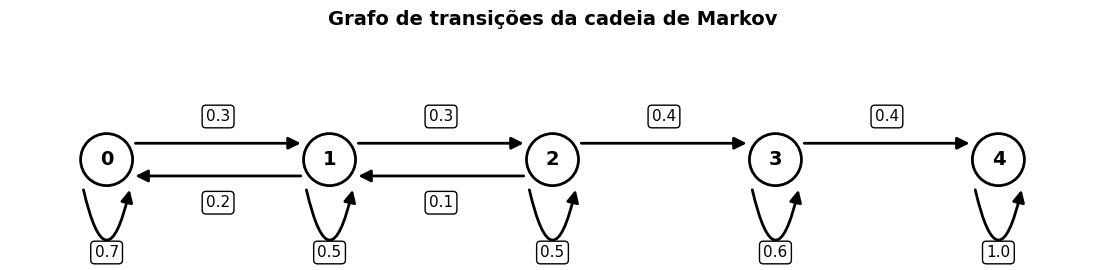

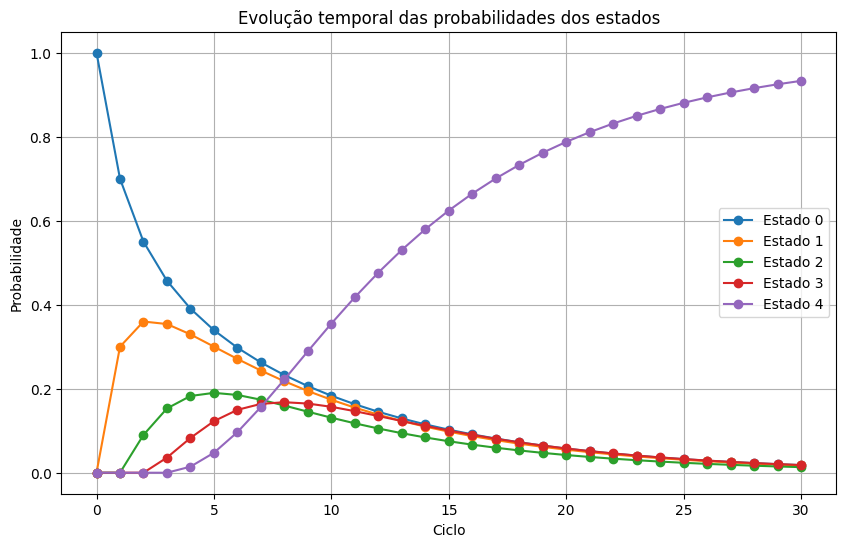

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ============================================================
# 1) Definição da matriz de transição
# ============================================================

P = np.array([
    [0.7, 0.3, 0.0, 0.0, 0.0],
    [0.2, 0.5, 0.3, 0.0, 0.0],
    [0.0, 0.1, 0.5, 0.4, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

estados = [0, 1, 2, 3, 4]

np.set_printoptions(precision=4, suppress=True)

print("Matriz de transição P:")
print(P)

# ============================================================
# 2) Cálculo das probabilidades
# ============================================================

# Probabilidade de o sensor atingir o estado 4 no 4º ciclo
# Como o menor caminho de 0 até 4 possui 4 transições,
# P^4[0,4] representa a probabilidade de atingir a falha total no 4º ciclo.

P4 = np.linalg.matrix_power(P, 4)
prob_falha_4 = P4[0, 4]

print("\nMatriz P^4:")
print(P4)

print("\nProbabilidade de atingir a falha total no 4º ciclo:")
print(prob_falha_4)

# ============================================================
# 3) Matriz fundamental da cadeia absorvente
# ============================================================

# Estados transientes: 0, 1, 2, 3
# Estado absorvente: 4

Q = P[:4, :4]
R = P[:4, 4:]

I = np.eye(Q.shape[0])

# Matriz fundamental
N = np.linalg.inv(I - Q)

print("\nMatriz Q:")
print(Q)

print("\nMatriz R:")
print(R)

print("\nMatriz fundamental N = (I - Q)^(-1):")
print(N)

# ============================================================
# 4) Número médio de ciclos até a absorção
# ============================================================

um = np.ones((Q.shape[0], 1))
tempo_absorcao = N @ um

print("\nNúmero médio de ciclos até a absorção:")
for estado, tempo in zip(estados[:4], tempo_absorcao.flatten()):
    print(f"Estado inicial {estado}: {tempo:.4f} ciclos")

# ============================================================
# 5) Probabilidade de absorção no estado 4
# ============================================================

B = N @ R

print("\nProbabilidade de absorção no estado 4:")
for estado, prob in zip(estados[:4], B.flatten()):
    print(f"Estado inicial {estado}: {prob:.4f}")

print("Estado inicial 4: 1.0000")

# ============================================================
# 6) Simulação da cadeia de Markov
# ============================================================

def simular_cadeia(P, estado_inicial=0, max_ciclos=100, seed=42):
    rng = np.random.default_rng(seed)
    estado_atual = estado_inicial
    caminho = [estado_atual]

    for ciclo in range(max_ciclos):
        estado_atual = rng.choice(len(P), p=P[estado_atual])
        caminho.append(estado_atual)

        if estado_atual == 4:
            break

    return caminho

caminho = simular_cadeia(P, estado_inicial=0, max_ciclos=100, seed=10)

print("\nCaminho simulado da cadeia:")
print(caminho)

print("\nNúmero de ciclos até a falha total na simulação:")
print(len(caminho) - 1)

# ============================================================
# 7) Plotar o grafo de transições - versão clara
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 5))

# Posições dos estados
pos = {
    0: 0,
    1: 3,
    2: 6,
    3: 9,
    4: 12
}

y = 0
raio = 0.35

# Probabilidades de permanecer no mesmo estado
auto_transicoes = {
    0: 0.7,
    1: 0.5,
    2: 0.5,
    3: 0.6,
    4: 1.0
}

# Desenhar os estados
for estado, x in pos.items():
    circulo = Circle(
        (x, y),
        raio,
        facecolor="white",
        edgecolor="black",
        linewidth=2,
        zorder=3
    )
    ax.add_patch(circulo)

    ax.text(
        x, y,
        str(estado),
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        zorder=4
    )

# Desenhar auto-transições: 0->0, 1->1, 2->2, 3->3, 4->4
for estado, prob in auto_transicoes.items():
    x = pos[estado]

    loop = FancyArrowPatch(
        (x - 0.32, y + 0.37),
        (x + 0.32, y + 0.37),
        connectionstyle="arc3,rad=-2.2",
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=2,
        color="black",
        zorder=2,
        clip_on=False
    )

    ax.add_patch(loop)

    ax.text(
        x,
        y + 1.25,
        f"{prob:.1f}",
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.25"),
        zorder=5
    )

# Função para desenhar seta entre estados diferentes
def desenhar_seta(origem, destino, prob, tipo):
    x1 = pos[origem]
    x2 = pos[destino]

    if tipo == "frente":
        y_seta = 0.22
        y_texto = 0.58

        inicio = (x1 + raio, y_seta)
        fim = (x2 - raio, y_seta)

    elif tipo == "volta":
        y_seta = -0.22
        y_texto = -0.58

        inicio = (x1 - raio, y_seta)
        fim = (x2 + raio, y_seta)

    seta = FancyArrowPatch(
        inicio,
        fim,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=2,
        color="black",
        zorder=1
    )

    ax.add_patch(seta)

    ax.text(
        (x1 + x2) / 2,
        y_texto,
        f"{prob:.1f}",
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.25"),
        zorder=5
    )

# Transições de degradação
desenhar_seta(0, 1, 0.3, "frente")
desenhar_seta(1, 2, 0.3, "frente")
desenhar_seta(2, 3, 0.4, "frente")
desenhar_seta(3, 4, 0.4, "frente")

# Transições de recuperação parcial
desenhar_seta(1, 0, 0.2, "volta")
desenhar_seta(2, 1, 0.1, "volta")

# Ajustes finais
ax.set_xlim(-1.3, 13.3)
ax.set_ylim(-1.0, 1.7)
ax.set_aspect("equal")
ax.axis("off")

ax.set_title(
    "Grafo de transições da cadeia de Markov",
    fontsize=14,
    fontweight="bold"
)

plt.show()
# ============================================================
# 8) Evolução temporal das probabilidades dos estados
# ============================================================

# O sensor começa no estado 0
p0 = np.array([1, 0, 0, 0, 0])

n_ciclos = 30
historico = []

for n in range(n_ciclos + 1):
    pn = p0 @ np.linalg.matrix_power(P, n)
    historico.append(pn)

historico = np.array(historico)

plt.figure(figsize=(10, 6))

for estado in estados:
    plt.plot(
        range(n_ciclos + 1),
        historico[:, estado],
        marker="o",
        label=f"Estado {estado}"
    )

plt.xlabel("Ciclo")
plt.ylabel("Probabilidade")
plt.title("Evolução temporal das probabilidades dos estados")
plt.legend()
plt.grid(True)
plt.show()